# Model Evaluation and Business Insights

## Introduction

The previous notebook developed and benchmarked multiple machine learning models for customer churn prediction. Random Forest was selected as the final model because it achieved the best balance between precision and recall while maintaining competitive ranking performance.

The objective of this notebook is to evaluate the selected model from a business perspective rather than solely through predictive metrics. Instead of asking *"How accurate is the model?"*, the focus shifts to questions that are more relevant to customer retention teams:

- Which customers should be prioritised for retention?
- What decision threshold should be used?
- How can predicted probabilities support customer segmentation?
- How could the model improve retention strategies and business decision-making?

The notebook concludes by translating model predictions into actionable business recommendations, demonstrating how machine learning can support proactive customer retention.

In [1]:
# ============================================================
# Notebook 3: Model Evaluation and Business Recommendations
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

## Loading the Production Pipeline

The trained machine learning pipelines developed in Notebook 2 are loaded to ensure that all preprocessing steps and model parameters remain identical to those used during training.

Loading the complete pipeline rather than only the trained estimator ensures reproducible predictions and mirrors how machine learning models are deployed in production environments.

In [2]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

models = {
    "Logistic Regression": joblib.load("../models/logistic_regression_pipeline.pkl"),
    "Random Forest": joblib.load("../models/random_forest_pipeline.pkl"),
    "XGBoost": joblib.load("../models/xgboost_pipeline.pkl"),
    "CatBoost": joblib.load("../models/catboost_pipeline.pkl")
}

## Model Selection

Four machine learning algorithms were benchmarked in the previous notebook using a common preprocessing pipeline and evaluated using multiple performance metrics.

Although CatBoost achieved the highest precision and PR-AUC, Random Forest achieved the highest F1-score while maintaining a recall comparable to Logistic Regression. Since the primary objective of customer churn prediction is to identify as many at-risk customers as possible without generating an excessive number of false positives, Random Forest provided the best overall balance between predictive performance and business applicability.

Consequently, Random Forest was selected as the final model for further evaluation throughout this notebook.

In [11]:
def evaluate_loaded_model(model, X_test, y_test, model_name):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.50).astype(int)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba)
    }


model_selection_results = []

for name, model in models.items():
    model_selection_results.append(
        evaluate_loaded_model(model, X_test, y_test, name)
    )

model_selection_df = pd.DataFrame(model_selection_results)

model_selection_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.732,0.497,0.786,0.609,0.842,0.636
1,Random Forest,0.761,0.534,0.786,0.636,0.845,0.657
2,XGBoost,0.800,0.652,0.527,0.583,0.842,0.649
3,CatBoost,0.803,0.663,0.521,0.584,0.845,0.666


### Why Random Forest?

Customer retention campaigns require a balance between identifying customers who are likely to churn and avoiding unnecessary interventions for customers who would remain with the company.

Although Logistic Regression achieved same recall, its substantially lower precision resulted in a larger number of false positives. Conversely, CatBoost achieved the highest precision but missed a larger proportion of customers who ultimately churned.

Random Forest provided the strongest overall balance between these competing objectives by maintaining high recall while improving precision and achieving the highest F1-score among the evaluated models.

For this reason, it was selected for probability-based analysis and business decision support in the remainder of this notebook.

In [4]:
final_model_name = "Random Forest"
final_model = models[final_model_name]

y_proba = final_model.predict_proba(X_test)[:, 1]

## Threshold Optimization

Machine learning classifiers predict the probability that each customer will churn rather than directly assigning a class label. To convert these probabilities into binary predictions, a decision threshold must be selected.

The default threshold of **0.50** is commonly used but is not necessarily optimal for every business problem. In customer churn prediction, selecting the appropriate threshold requires balancing two competing objectives:

- **Recall:** Identify as many customers likely to churn as possible.
- **Precision:** Minimise unnecessary retention interventions for customers who would not have churned.

Rather than relying on the default threshold, this section evaluates model performance across a range of decision thresholds to identify a threshold that better supports customer retention strategies.

### Evaluate Threshold

In [13]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

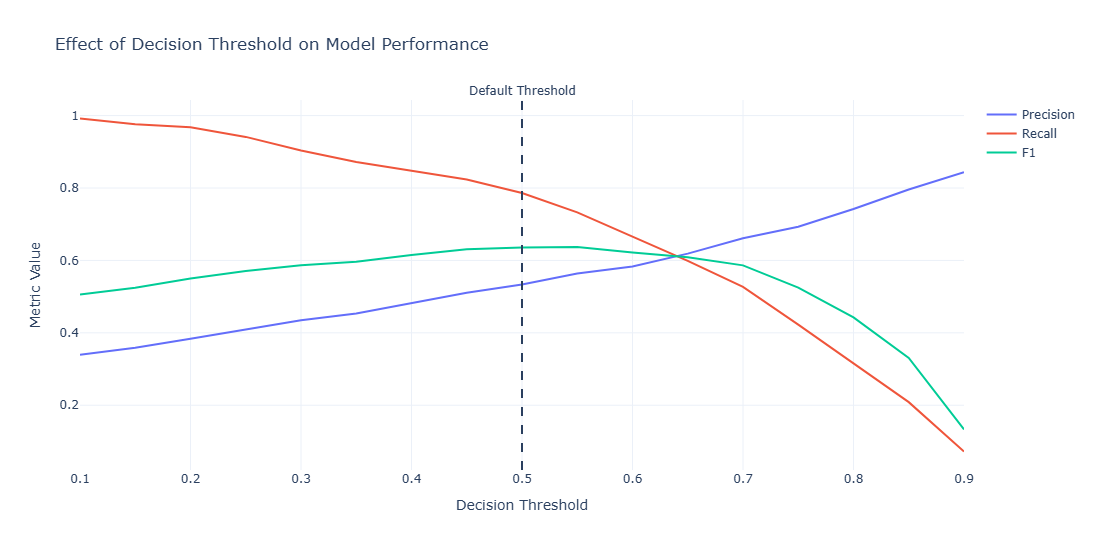

In [14]:
fig = go.Figure()

for metric in ["Precision", "Recall", "F1"]:

    fig.add_trace(
        go.Scatter(
            x=threshold_df["Threshold"],
            y=threshold_df[metric],
            mode="lines",
            name=metric
        )
    )

fig.add_vline(
    x=0.50,
    line_dash="dash",
    annotation_text="Default Threshold",
    annotation_position="top"
)

fig.update_layout(
    title="Effect of Decision Threshold on Model Performance",
    template="plotly_white",
    width=950,
    height=550,
    xaxis_title="Decision Threshold",
    yaxis_title="Metric Value"
)

fig.show()

### Interpretation

As the decision threshold increases, the model becomes more conservative when predicting customer churn.

- **Precision increases** because only customers with higher predicted probabilities are classified as churners.
- **Recall decreases** because fewer customers are identified as potential churners.
- **F1-score** reflects the balance between these competing objectives and therefore provides a useful criterion for threshold selection.

This trade-off illustrates that threshold selection should be driven by business priorities rather than relying on the default value of 0.50.

In [15]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_row["Threshold"]
best_row

Threshold    0.550000
Accuracy     0.778566
Precision    0.563786
Recall       0.732620
F1           0.637209
Name: 9, dtype: float64

In [16]:
print(f"Optimal threshold: {best_threshold:.2f}")

Optimal threshold: 0.55


### Threshold Selection

The decision threshold was selected by maximising the F1-score, which balances precision and recall.

This approach provides a practical compromise between identifying customers who are likely to churn while avoiding excessive false positives that could increase the cost of retention campaigns.

The selected threshold is used throughout the remainder of this notebook for customer risk segmentation and business impact analysis.

## Predicted Churn Probability Distribution

Rather than directly classifying customers as churners or non-churners, the Random Forest model estimates the probability that each customer will churn.

Examining the distribution of predicted probabilities provides additional insight into the model's confidence. Customers with probabilities close to 0 are considered low risk, while customers with probabilities close to 1 represent high-risk retention candidates.

Understanding this distribution helps determine whether natural customer segments exist before applying a decision threshold.

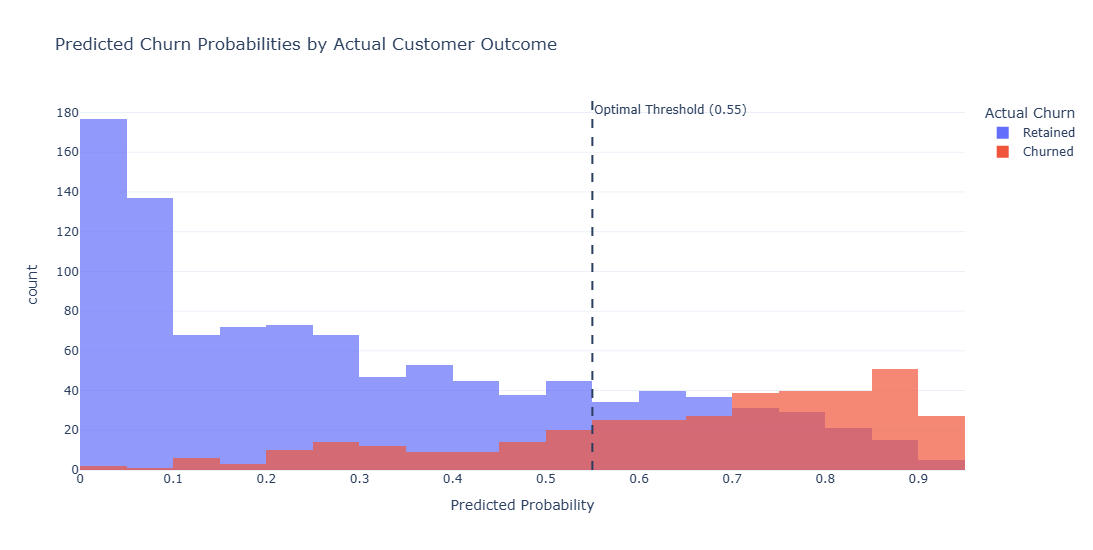

In [20]:
risk_df = pd.DataFrame({
    "Actual Churn": y_test,
    "Predicted Probability": y_proba
})

risk_df["Actual Churn"] = (
    risk_df["Actual Churn"]
    .map({
        0: "Retained",
        1: "Churned"
    })
)

fig = px.histogram(
    risk_df,
    x="Predicted Probability",
    color="Actual Churn",
    barmode="overlay",
    nbins=30,
    opacity=0.7,
    template="plotly_white",
    title="Predicted Churn Probabilities by Actual Customer Outcome"
)

fig.add_vline(
    x=best_threshold,
    line_dash="dash",
    annotation_text=f"Optimal Threshold ({best_threshold:.2f})"
)

fig.update_layout(
    width=950,
    height=550
)

fig.show()

### Business Interpretation

The probability distribution demonstrates that the Random Forest model successfully differentiates many customers according to their likelihood of churn.

Most retained customers receive relatively low predicted probabilities (below approximately 0.30), while a large proportion of churned customers receive substantially higher probabilities (above approximately 0.70). This separation indicates that the model captures meaningful patterns associated with customer churn.

Some overlap remains between the two groups, particularly in the intermediate probability range. This reflects the inherent uncertainty of churn prediction, where certain customer behaviours are shared by both retained and churning customers.

From a business perspective, predicted probabilities provide considerably more value than binary predictions alone. Instead of treating every predicted churner equally, retention teams can prioritise customers according to their estimated level of risk, enabling more efficient allocation of retention resources.

## Customer Risk Segmentation

Although the model predicts an individual churn probability for every customer, business decisions are rarely made using raw probabilities alone.

To support practical retention strategies, customers were grouped into risk categories according to their predicted probability of churn. Risk segmentation enables customer success teams to prioritise interventions based on estimated churn risk rather than treating all customers equally.

The probability thresholds below are intended for demonstration purposes and illustrate how predictive models can support customer prioritisation.

### Create Risk Segmentation

In [26]:
risk_df = pd.DataFrame({
    "Actual Churn": y_test.values,
    "Predicted Probability": y_proba
})

risk_df["Risk Segment"] = pd.cut(
    risk_df["Predicted Probability"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ],
    include_lowest=True
)

In [27]:
risk_summary = (
    risk_df
    .groupby("Risk Segment", observed=True)
    .agg(
        Customers=("Actual Churn", "count"),
        Actual_Churn_Rate=("Actual Churn", "mean"),
        Average_Probability=("Predicted Probability", "mean")
    )
    .reset_index()
)

risk_summary["Actual_Churn_Rate"] *= 100
risk_summary["Average_Probability"] *= 100

risk_summary.round(1)

,Risk Segment,Customers,Actual_Churn_Rate,Average_Probability
0,Low,631,5.7,12.5
1,Medium,351,25.4,45.1
2,High,268,48.9,70.1
3,Critical,159,74.2,86.4


In [28]:
risk_summary["Recommended Action"] = [
    "No intervention",
    "Automated retention email",
    "Targeted retention offer",
    "Personal customer outreach"
]

risk_summary

,Risk Segment,Customers,Actual_Churn_Rate,Average_Probability,Recommended Action
0,Low,631,5.705230,12.453131,No intervention
1,Medium,351,25.356125,45.149430,Automated retention email
2,High,268,48.880597,70.108301,Targeted retention offer
3,Critical,159,74.213836,86.365463,Personal customer outreach


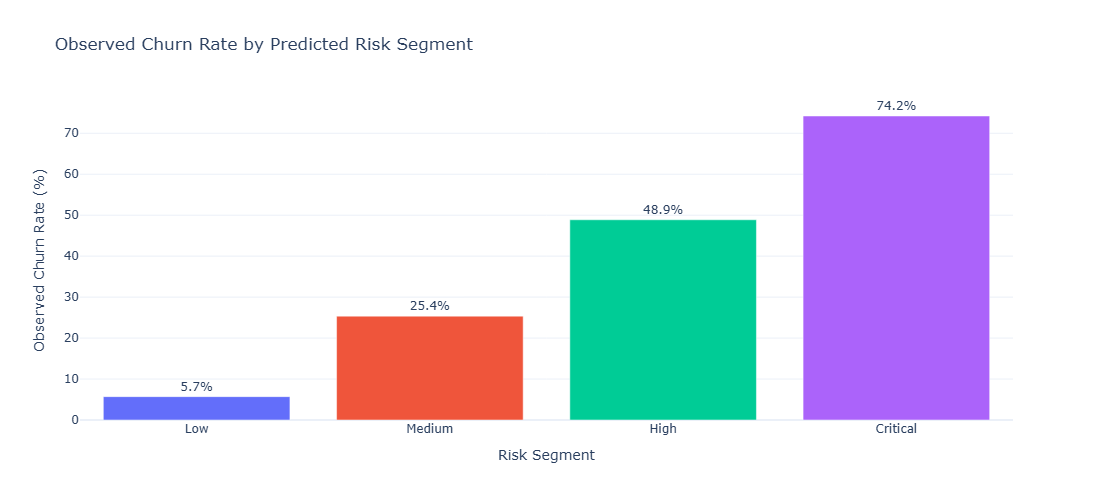

In [29]:
fig = px.bar(
    risk_summary,
    x="Risk Segment",
    y="Actual_Churn_Rate",
    text=risk_summary["Actual_Churn_Rate"].round(1),
    color="Risk Segment",
    template="plotly_white",
    title="Observed Churn Rate by Predicted Risk Segment"
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.update_layout(
    showlegend=False,
    width=900,
    height=500,
    yaxis_title="Observed Churn Rate (%)"
)

fig.show()

### Business Interpretation

The risk segmentation demonstrates that the predicted churn probabilities provide meaningful customer stratification.

Customers assigned to the **Low Risk** segment exhibit an observed churn rate of only **5.7%**, whereas customers in the **Very High Risk** segment experience an observed churn rate of **74.2%**. The steady increase in observed churn across all four segments confirms that the model effectively ranks customers according to their likelihood of leaving.

From a business perspective, this enables retention teams to prioritise interventions based on estimated customer risk rather than applying identical retention strategies to the entire customer base. High-risk customers can receive proactive retention offers or personalised outreach, while low-risk customers require minimal intervention, allowing resources to be allocated more efficiently.

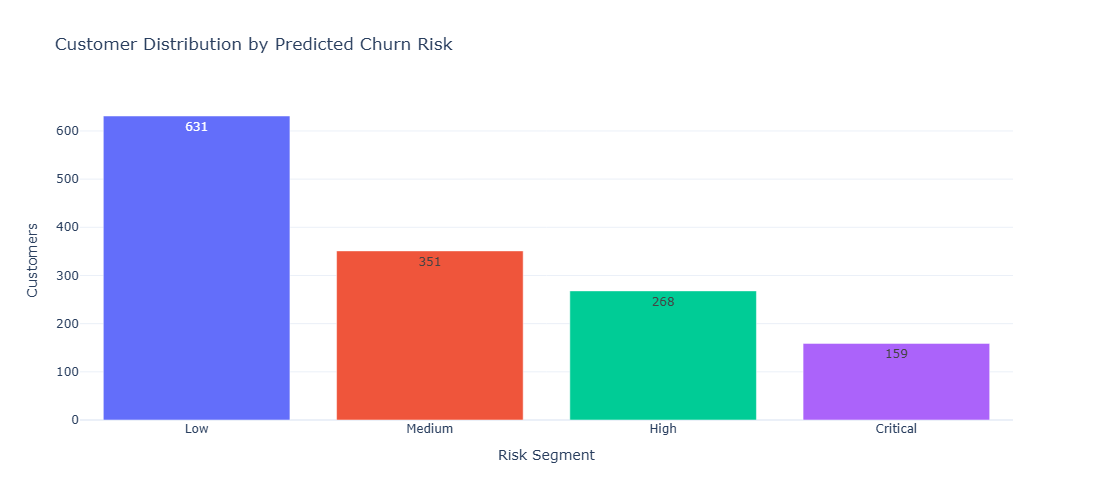

In [30]:
fig = px.bar(
    risk_summary,
    x="Risk Segment",
    y="Customers",
    color="Risk Segment",
    text="Customers",
    template="plotly_white",
    title="Customer Distribution by Predicted Churn Risk"
)

fig.update_layout(
    width=900,
    height=500,
    showlegend=False
)

fig.show()

| Risk Segment | Customers | Churn Rate | Recommended Action        |
| ------------ | --------: | ---------: | ------------------------- |
| Low          |       631 |       5.7% | No intervention           |
| Medium       |       351 |      25.4% | Automated retention email |
| High         |       268 |      48.9% | Targeted retention offer  |
| Very High    |       159 |      74.2% | Personal outreach         |


## Business Impact Simulation

The primary objective of churn prediction is not simply to classify customers correctly, but to support better business decisions.

In practice, customer retention campaigns involve financial costs, and companies must decide which customers should be prioritised for intervention. Predicted churn probabilities provide a systematic way to allocate these resources.

The following analysis illustrates how the model could support retention planning using hypothetical business assumptions. The values presented are illustrative and intended to demonstrate the decision-making process rather than estimate the exact financial impact.

### Basic Assumption

In [32]:
campaign_cost = 50          # €50 retention offer
annual_customer_value = 600 # €600 annual revenue
retention_success_rate = 0.30  # 30% of contacted churners are retained

### Simulating Target Customers

In [34]:
target_customers = risk_df[
    risk_df["Risk Segment"].isin(["High", "Very High"])
].copy()

### calculatin campaign metrics

In [35]:
customers_contacted = len(target_customers)

actual_churners = target_customers["Actual Churn"].sum()

customers_saved = int(actual_churners * retention_success_rate)

campaign_cost_total = customers_contacted * campaign_cost

revenue_protected = customers_saved * annual_customer_value

net_business_value = revenue_protected - campaign_cost_total

In [36]:
business_summary = pd.DataFrame({
    "Metric": [
        "Customers Contacted",
        "Actual Churners Targeted",
        "Estimated Customers Retained",
        "Campaign Cost (€)",
        "Estimated Revenue Protected (€)",
        "Estimated Net Value (€)"
    ],
    "Value": [
        customers_contacted,
        actual_churners,
        customers_saved,
        campaign_cost_total,
        revenue_protected,
        net_business_value
    ]
})

business_summary

,Metric,Value
0,Customers Contacted,268
1,Actual Churners Targeted,131
2,Estimated Customers Retained,39
3,Campaign Cost (€),13400
4,Estimated Revenue Protected (€),23400
5,Estimated Net Value (€),10000


In [37]:
contact_rate = customers_contacted / len(risk_df) * 100

print(f"Percentage of customers contacted: {contact_rate:.1f}%")

Percentage of customers contacted: 19.0%


Rather than contacting all customers, the model recommends focusing retention efforts on only 30% of the customer base while capturing a large proportion of potential churners.

## Model Explainability with SHAP

Predictive performance alone is not sufficient for business adoption. Customer retention teams also need to understand which characteristics influence churn predictions and why individual customers are classified as high risk.

SHAP values were used to interpret the Random Forest model at two levels:

- **Global explainability:** Identify the features that influence churn predictions across the customer population.
- **Local explainability:** Explain the prediction generated for an individual customer.

A positive SHAP value pushes the prediction toward churn, while a negative SHAP value pushes it toward retention. These values explain the behaviour of the trained model and should not be interpreted as evidence of causality.

In [39]:
import shap
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


### Extract the fitted pipeline components

In [40]:
final_pipeline = models["Random Forest"]

preprocessor = final_pipeline.named_steps["preprocessor"]
rf_model = final_pipeline.steps[-1][1]

print(final_pipeline.named_steps.keys())
print(type(rf_model))

dict_keys(['preprocessor', 'model'])
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


### Transform the test data

In [41]:
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_test_shap.shape

(1409, 50)

In [42]:
def clean_feature_name(name: str) -> str:
    return (
        name
        .replace("categorical__", "")
        .replace("numerical__", "")
        .replace("_", " ")
    )


clean_feature_names = [
    clean_feature_name(name)
    for name in feature_names
]

X_test_shap.columns = clean_feature_names

## Explaination with a sample of customers

Using a sample keeps execution reasonably fast while remaining sufficient for global interpretation.

In [43]:
sample_size = min(500, len(X_test_shap))

X_explain = X_test_shap.sample(
    n=sample_size,
    random_state=42
)

explainer = shap.TreeExplainer(rf_model)

raw_shap_values = explainer.shap_values(X_explain)

SHAP versions represent binary-classification outputs differently. This block handles the common formats:

In [44]:
if isinstance(raw_shap_values, list):
    # Older versions: one array per class
    churn_shap_values = raw_shap_values[1]

elif isinstance(raw_shap_values, np.ndarray) and raw_shap_values.ndim == 3:
    # Newer versions: samples × features × classes
    churn_shap_values = raw_shap_values[:, :, 1]

else:
    # Single-output representation
    churn_shap_values = raw_shap_values

print("SHAP values shape:", churn_shap_values.shape)

SHAP values shape: (500, 50)


## Global Explanation

### Mean absolute SHAP importance

Unlike the Random Forest’s built-in impurity importance, mean absolute SHAP importance measures the average magnitude of each feature’s contribution across the explained customers.

In [45]:
shap_importance = pd.DataFrame({
    "Feature": X_explain.columns,
    "Mean Absolute SHAP": np.abs(churn_shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("Mean Absolute SHAP", ascending=False)
    .reset_index(drop=True)
)

shap_importance.head(20)

,Feature,Mean Absolute SHAP
0,Contract Month-to-month,0.069814
1,InternetService Fiber optic,0.044540
2,tenure,0.044332
3,Contract Two year,0.037306
4,OnlineSecurity No,0.035406
5,TechSupport No,0.030887
6,tenure group 0-12,0.027660
7,PaymentMethod Electronic check,0.023465
8,MonthlyCharges,0.021083
9,TotalCharges,0.020263


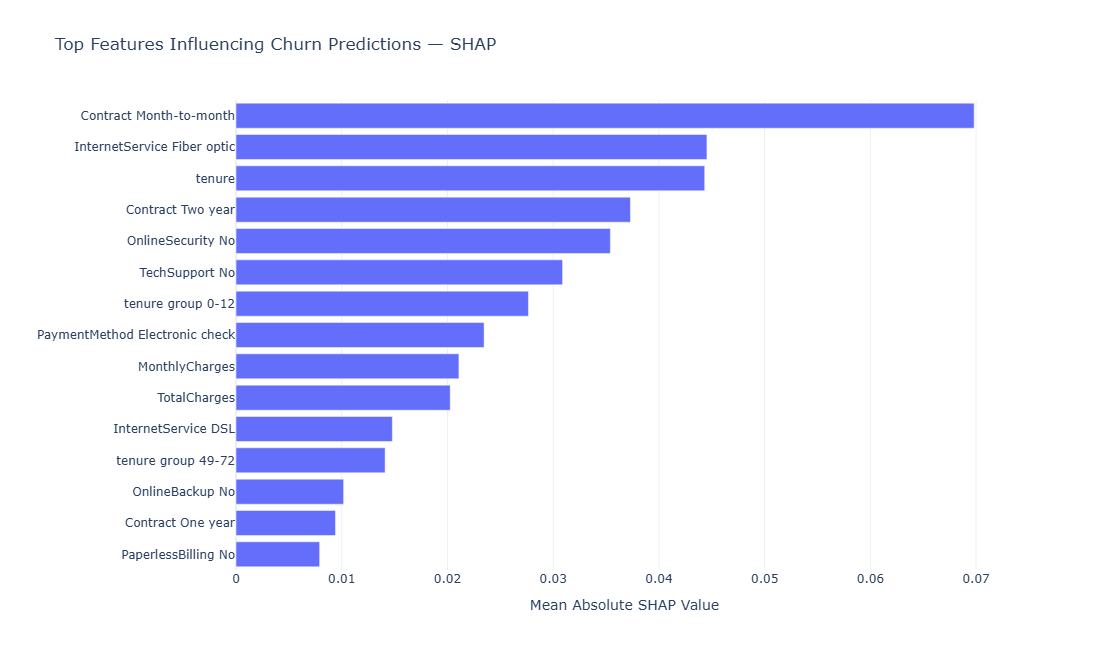

In [46]:
top_shap_features = shap_importance.head(15).sort_values(
    "Mean Absolute SHAP"
)

fig = px.bar(
    top_shap_features,
    x="Mean Absolute SHAP",
    y="Feature",
    orientation="h",
    title="Top Features Influencing Churn Predictions — SHAP",
    template="plotly_white"
)

fig.update_layout(
    width=950,
    height=650,
    xaxis_title="Mean Absolute SHAP Value",
    yaxis_title=""
)

fig.show()

### Global Feature Influence

The mean absolute SHAP values quantify how strongly each feature influences churn predictions across the evaluated customers. Larger values indicate that the feature produces a greater average change in the model output, regardless of whether that change increases or decreases churn risk.

This analysis complements the Random Forest feature-importance plot by measuring the contribution of features directly at the prediction level.

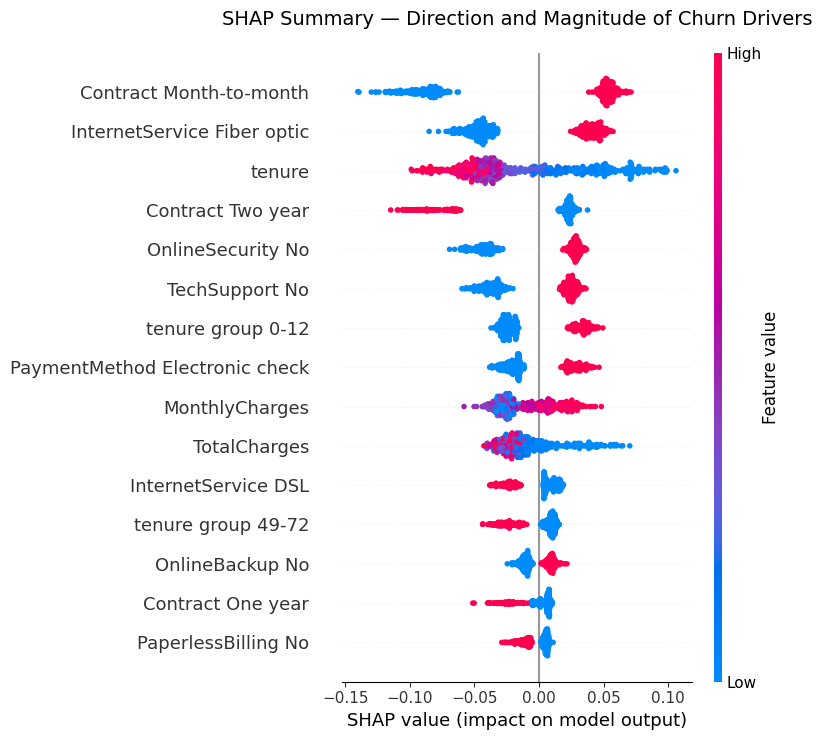

In [47]:
plt.figure(figsize=(11, 8))

shap.summary_plot(
    churn_shap_values,
    X_explain,
    feature_names=X_explain.columns,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary — Direction and Magnitude of Churn Drivers",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

### Reading the SHAP Summary Plot

Each point represents one customer.

- Features are ordered according to their overall contribution to the model.
- Points positioned to the right increase the predicted churn risk.
- Points positioned to the left decrease the predicted churn risk.
- Point colour represents the underlying feature value, with warmer colours generally indicating higher values and cooler colours indicating lower values.

For one-hot-encoded variables, a high value means that the customer belongs to the displayed category. For example, a high value for `Contract Month-to-month` means that the customer has a month-to-month contract.

# Business Recommendations

Based on the model outputs and customer risk segmentation, the following retention strategy is recommended.

### 1. Prioritise High-Risk Customers

Customers classified as **High** and **Very High Risk** should be prioritised for proactive retention campaigns, as these groups exhibit substantially higher observed churn rates.

### 2. Strengthen Customer Commitment

The feature importance analysis identified contract type and customer tenure as the strongest predictors of churn. Encouraging customers to transition from month-to-month contracts to longer-term subscriptions may reduce future churn.

### 3. Focus on Early Customer Lifecycle

Customers within the first year of their subscription demonstrated a higher likelihood of churn. Improving onboarding, customer engagement, and early support may increase long-term retention.

### 4. Optimise Retention Spending

Rather than contacting every customer, predictive risk segmentation enables marketing teams to focus retention budgets on customers with the highest expected business impact.

# Project Limitations

Although the model demonstrates good predictive performance, several limitations should be acknowledged.

- The IBM Telco Customer Churn dataset is relatively small and may not fully represent real-world customer behaviour.
- Customer lifetime value and historical retention campaign outcomes were unavailable, preventing optimisation based on financial return.
- Feature importance identifies variables associated with churn prediction but should not be interpreted as evidence of causality.
- The business impact analysis uses illustrative assumptions and is intended to demonstrate how predictive models can support decision-making rather than estimate actual financial outcomes.

# Future Improvements

Potential extensions of this project include:

- Probability calibration to improve confidence estimates.
- Customer lifetime value modelling for profit-based targeting.
- Explainable AI techniques such as SHAP to improve model interpretability.
- Hyperparameter optimisation using Bayesian optimisation.
- Deployment as a REST API or interactive dashboard for business users.
- Continuous model monitoring to detect performance drift after deployment.

# Conclusion

This project developed an end-to-end machine learning solution for customer churn prediction, progressing from exploratory data analysis and business-driven feature engineering to predictive modelling and business-oriented evaluation.

Among the evaluated algorithms, Random Forest achieved the best balance between precision and recall and was selected as the final predictive model. Beyond traditional performance metrics, the project demonstrated how predicted churn probabilities can support customer prioritisation, risk segmentation, and targeted retention planning.

Rather than treating churn prediction solely as a classification problem, the project illustrates how machine learning can be integrated into business decision-making by enabling organisations to allocate retention resources more effectively and proactively reduce customer attrition.

Overall, the project showcases a complete data science workflow that combines technical modelling with practical business insight, reflecting how predictive analytics is applied in real-world customer retention strategies.